In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sqlite3

In [2]:
df = pd.read_csv("Hospital ER_Data.csv")
df.head()

,Patient Id,Patient Admission Date,Patient First Inital,Patient Last Name,Patient Gender,Patient Age,Patient Race,Department Referral,Patient Admission Flag,Patient Satisfaction Score,Patient Waittime,Patients CM
0,145-39-5406,20-03-2024 08:47,H,Glasspool,M,69,White,NaN,False,10.0,39,0
1,316-34-3057,15-06-2024 11:29,X,Methuen,M,4,Native American/Alaska Native,NaN,True,NaN,27,0
2,897-46-3852,20-06-2024 09:13,P,Schubuser,F,56,African American,General Practice,True,9.0,55,0
3,358-31-9711,04-02-2024 22:34,U,Titcombe,F,24,Native American/Alaska Native,General Practice,True,8.0,31,0
4,289-26-0537,04-09-2024 17:48,Y,Gionettitti,M,5,African American,Orthopedics,False,NaN,10,0


In [3]:
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9216 entries, 0 to 9215
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Patient Id                  9216 non-null   object 
 1   Patient Admission Date      9216 non-null   object 
 2   Patient First Inital        9216 non-null   object 
 3   Patient Last Name           9216 non-null   object 
 4   Patient Gender              9216 non-null   object 
 5   Patient Age                 9216 non-null   int64  
 6   Patient Race                9216 non-null   object 
 7   Department Referral         3816 non-null   object 
 8   Patient Admission Flag      9216 non-null   bool   
 9   Patient Satisfaction Score  2517 non-null   float64
 10  Patient Waittime            9216 non-null   int64  
 11  Patients CM                 9216 non-null   int64  
dtypes: bool(1), float64(1), int64(3), object(7)
memory usage: 801.1+ KB


,Patient Age,Patient Satisfaction Score,Patient Waittime,Patients CM
count,9216.000000,2517.000000,9216.000000,9216.000000
mean,39.855143,4.992054,35.259874,0.052083
std,22.755125,3.138043,14.735323,0.222207
min,1.000000,0.000000,10.000000,0.000000
25%,20.000000,2.000000,23.000000,0.000000
50%,39.000000,5.000000,35.000000,0.000000
75%,60.000000,8.000000,48.000000,0.000000
max,79.000000,10.000000,60.000000,1.000000


In [6]:
# Remove duplicates
df = df.drop_duplicates()

# Handle missing values
df = df.dropna()

# Convert date column (change name if needed)
df['Patient Admission Date'] = pd.to_datetime(df['Patient Admission Date'], errors='coerce')

In [8]:
df['Patient Admission Date'] = pd.to_datetime(df['Patient Admission Date'], errors='coerce')

df['Month'] = df['Patient Admission Date'].dt.month
df['Year'] = df['Patient Admission Date'].dt.year

In [9]:
df['Patient Gender'].value_counts()

Patient Gender
M     580
F     495
NC      2
Name: count, dtype: int64

In [10]:
df['Patient Age'].describe()

count    1077.000000
mean       39.810585
std        22.785638
min         1.000000
25%        21.000000
50%        39.000000
75%        60.000000
max        79.000000
Name: Patient Age, dtype: float64

In [11]:
df.groupby('Month').size()

Month
1      55
2      55
3      47
4     115
5     115
6     108
7     111
8     106
9     112
10    126
11     65
12     62
dtype: int64

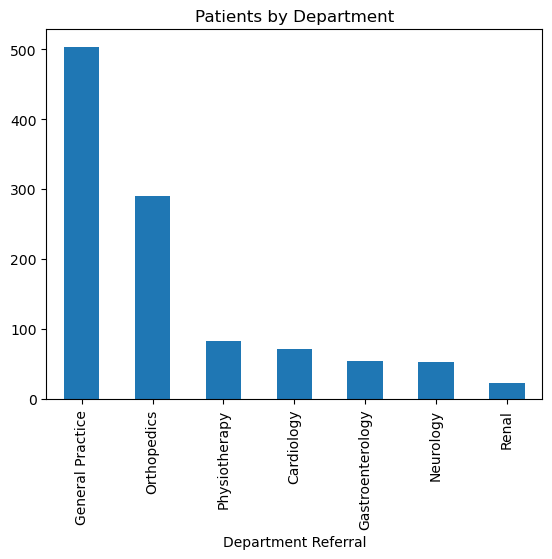

In [12]:
df['Department Referral'].value_counts().plot(kind='bar')
plt.title("Patients by Department")
plt.show()

In [13]:
conn = sqlite3.connect("hospital.db")
df.to_sql("hospital", conn, if_exists="replace", index=False)

1077

In [16]:
pd.read_sql("""
SELECT "Department Referral", COUNT(*) AS patient_count
FROM hospital
GROUP BY "Department Referral"
ORDER BY patient_count DESC;
""", conn)

,Department Referral,patient_count
0,General Practice,503
1,Orthopedics,290
2,Physiotherapy,83
3,Cardiology,71
4,Gastroenterology,54
5,Neurology,53
6,Renal,23


In [24]:
pd.read_sql("""
SELECT "Patient Gender", AVG("Patient Age") AS avg_age
FROM hospital
GROUP BY "Patient Gender";
""", conn)

,Patient Gender,avg_age
0,F,39.650505
1,M,39.858621
2,NC,65.500000


In [29]:
pd.read_sql("""
SELECT strftime('%m', "Patient Admission Date") AS month, COUNT(*) AS total
FROM hospital
GROUP BY month;
""", conn)

,month,total
0,01,55
1,02,55
2,03,47
3,04,115
4,05,115
5,06,108
6,07,111
7,08,106
8,09,112
9,10,126


In [30]:
pd.read_sql("""
SELECT *
FROM hospital
WHERE "Billing Amount" > 5000;
""", conn)

,Patient Id,Patient Admission Date,Patient First Inital,Patient Last Name,Patient Gender,Patient Age,Patient Race,Department Referral,Patient Admission Flag,Patient Satisfaction Score,Patient Waittime,Patients CM,Month,Year
0,897-46-3852,2024-06-20 09:13:00,P,Schubuser,F,56,African American,General Practice,1,9.0,55,0,6,2024
1,358-31-9711,2024-02-04 22:34:00,U,Titcombe,F,24,Native American/Alaska Native,General Practice,1,8.0,31,0,2,2024
2,278-49-6531,2024-08-05 01:33:00,L,Vannacci,F,74,White,Physiotherapy,0,0.0,20,0,8,2024
3,298-72-2588,2024-10-24 04:53:00,E,Lillistone,M,74,Two or More Races,General Practice,1,9.0,48,0,10,2024
4,509-88-2899,2023-09-23 23:51:00,F,Brudenell,M,14,Two or More Races,Orthopedics,1,4.0,23,0,9,2023
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1072,534-84-2695,2024-07-27 04:12:00,T,Edinborough,M,54,White,Physiotherapy,1,7.0,34,0,7,2024
1073,743-65-5099,2024-02-18 11:35:00,M,Peschmann,M,30,White,Physiotherapy,1,8.0,58,0,2,2024
1074,258-20-1592,2023-04-28 17:59:00,M,de Bullion,M,2,White,Physiotherapy,1,10.0,56,0,4,2023
1075,406-35-8082,2023-08-22 14:53:00,U,Caze,M,4,White,Renal,1,4.0,44,0,8,2023


In [31]:
print(df.columns)

Index(['Patient Id', 'Patient Admission Date', 'Patient First Inital',
       'Patient Last Name', 'Patient Gender', 'Patient Age', 'Patient Race',
       'Department Referral', 'Patient Admission Flag',
       'Patient Satisfaction Score', 'Patient Waittime', 'Patients CM',
       'Month', 'Year'],
      dtype='object')
